In [3]:

from utils.connector import postgres

def query(sql, params=None):
    with postgres() as pg:
        return pg.query(sql, params)

# Analiza jednostek

In [ ]:
sql_chembl_ic50_units_human = """select * from chembl_ic50_units_human"""

data_units = query(sql_chembl_ic50_units_human)



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Dane jednostek IC50 (ludzki, exact):")
print(data_units.head())

data_units_sorted = data_units.sort_values('n_records', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x='standard_units', y='n_records', data=data_units_sorted, palette='viridis')
plt.xticks(rotation=45)
plt.ylabel("Liczba rekordów")
plt.xlabel("Jednostka IC50")
plt.title("Rozkład liczby rekordów na jednostkę IC50")
plt.show()

plt.figure(figsize=(12,6))
for idx, row in data_units_sorted.iterrows():
    plt.plot([idx, idx], [row['min_value'], row['max_value']], color='gray', alpha=0.7)  # type: ignore # linia min-max
    plt.scatter(idx, row['median_value'], color='red', label='mediana' if idx==0 else "")  # type: ignore # mediana
plt.xticks(range(len(data_units_sorted)), data_units_sorted['standard_units'], rotation=45) # type: ignore
plt.ylabel("IC50 value")
plt.xlabel("Jednostka IC50")
plt.title("Rozkład wartości IC50 per jednostka (min-max i mediana)")
plt.legend()
plt.show()

data_units_sorted['convertible'] = data_units_sorted['standard_units'].isin(['pM','nM','uM','mM'])

plt.figure(figsize=(10,5))
sns.barplot(x='standard_units', y='n_records', hue='convertible', data=data_units_sorted, palette=['red','green'])
plt.xticks(rotation=45)
plt.ylabel("Liczba rekordów")
plt.xlabel("Jednostka IC50")
plt.title("Które jednostki można łatwo przekonwertować")
plt.show()


In [12]:
sql = """select * from chembl_pic50_compounds;"""

data = query(sql)

print(f"Compounds: {len(data)}")
print(f"Median assays / compound: {data['n_assays'].median():.1f}")
print(f"pIC50 range: {data['pIC50_median'].min():.2f} – {data['pIC50_median'].max():.2f}")
print(data.columns)

/home/pkuszn/repos/WSzI/src/notebooks/utils/connector.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, self.conn, params=params)


Compounds: 1024547
Median assays / compound: 1.0
pIC50 range: 2.03 – 11.00
Index(['canonical_smiles', 'n_assays', 'pIC50_mean', 'pIC50_median',
       'pIC50_min', 'pIC50_max'],
      dtype='object')


# Histogram median pIC50

Im wyższa wartość pIC50, tym bardziej aktywny związek.

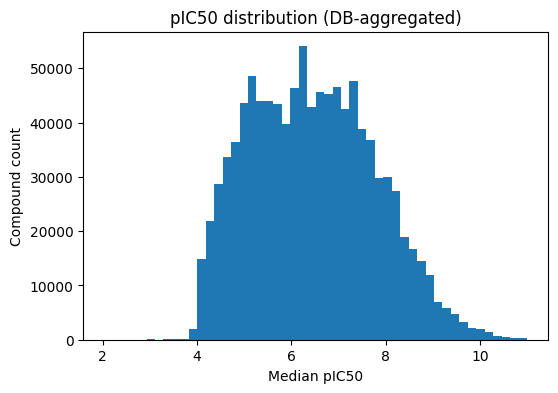

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(data['pIC50_median'], bins=50)
plt.xlabel("Median pIC50")
plt.ylabel("Compound count")
plt.title("pIC50 distribution (DB-aggregated)")
plt.show()

# Zmienność aktywności w obrębie każdego związku

- pIC50_range - rorzut aktywności danego związku
- Mały zakres - wszystkie assay są zbliżone, związek wydaje się stabilny
- Duży zakres - możliwe błędy pomiarowe, różne warunki eksperymentalne lub związek zachowuje się niestabilnie.

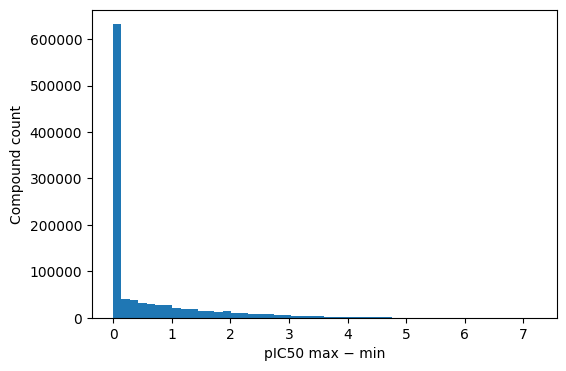

In [14]:
data['pIC50_range'] = data['pIC50_max'] - data['pIC50_min']

plt.figure(figsize=(6,4))
plt.hist(data['pIC50_range'], bins=50)
plt.xlabel("pIC50 max − min")
plt.ylabel("Compound count")
plt.show()

# Ile procent zwiążków ma niepewne (rozbieżne) wartości pIC50 ?

In [15]:
data['noisy'] = data['pIC50_range'] > 1.0
print(f"Noisy compounds: {data['noisy'].mean()*100:.1f}%")

Noisy compounds: 19.6%


# Liczba assayów na związek


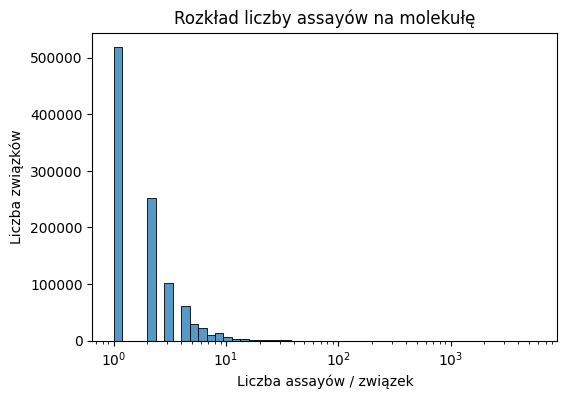

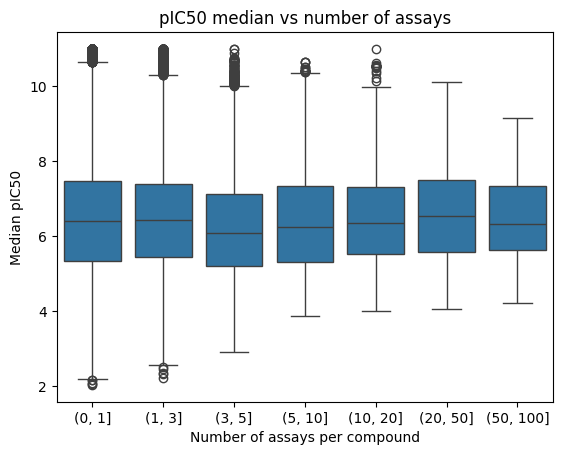

In [ ]:
import seaborn as sns
import pandas as pd

plt.figure(figsize=(6,4))
sns.histplot(data['n_assays'], bins=50, log_scale=(True, False)) # type: ignore
plt.xlabel("Liczba assayów / związek")
plt.ylabel("Liczba związków")
plt.title("Rozkład liczby assayów na molekułę")
plt.show()

sns.boxplot(x=pd.cut(data['n_assays'], bins=[0,1,3,5,10,20,50,100]), y=data['pIC50_median'])
plt.xlabel("Number of assays per compound")
plt.ylabel("Median pIC50")
plt.title("pIC50 median vs number of assays")
plt.show()

# Korelacje między statystykami


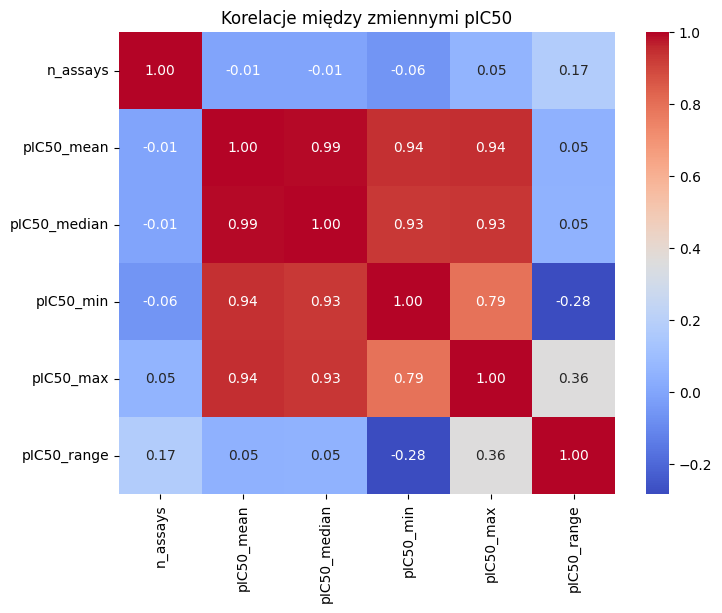

In [18]:
corr = data[['n_assays', 'pIC50_mean', 'pIC50_median', 'pIC50_min', 'pIC50_max', 'pIC50_range']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Korelacje między zmiennymi pIC50")
plt.show()

# Analiza noisy compounds

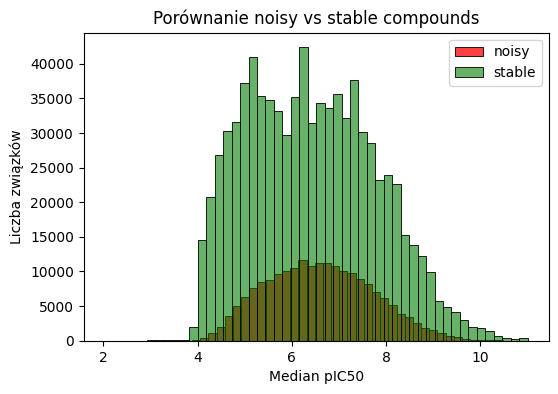

In [19]:
plt.figure(figsize=(6,4))
sns.histplot(data[data['noisy']==True]['pIC50_median'], bins=50, color='red', label='noisy')
sns.histplot(data[data['noisy']==False]['pIC50_median'], bins=50, color='green', label='stable', alpha=0.6)
plt.xlabel("Median pIC50")
plt.ylabel("Liczba związków")
plt.title("Porównanie noisy vs stable compounds")
plt.legend()
plt.show()

# Analiza zależności między medianą a rozrzutem

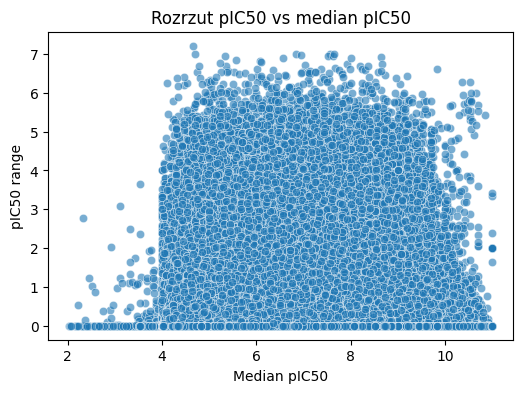

In [20]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='pIC50_median', y='pIC50_range', data=data, alpha=0.6)
plt.xlabel("Median pIC50")
plt.ylabel("pIC50 range")
plt.title("Rozrzut pIC50 vs median pIC50")
plt.show()